# Train Supervised CNN Classifier



In [1]:
import sys
from pathlib import Path

# Detect project root
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

assert PROJECT_ROOT.name == "image_classification_project", (
    f"Wrong working directory: {PROJECT_ROOT}. "
    "Launch Jupyter from image_classification_project."
)

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch version:", torch.__version__)
print("Device:", device)

Torch version: 2.12.1+cpu
Device: cpu


In [3]:
from src.data import get_datasets, get_dataloaders, compute_class_weights

train_dataset, val_dataset, test_dataset = get_datasets()

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print("Classes:")
print(train_dataset.classes)

print("Class to index:")
print(train_dataset.class_to_idx)

Train images: 995
Validation images: 213
Test images: 214
Classes:
['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']
Class to index:
{'ArtDeco': 0, 'Cubism': 1, 'Impressionism': 2, 'Japonism': 3, 'Naturalism': 4, 'Rococo': 5, 'cartoon': 6, 'photo': 7}


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=32,
    num_workers=0,
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("Min pixel value after normalization:", images.min().item())
print("Max pixel value after normalization:", images.max().item())
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Min pixel value after normalization: -2.1179039478302
Max pixel value after normalization: 2.640000104904175
Labels: tensor([4, 3, 0, 7, 5, 4, 4, 0, 3, 5])


In [5]:
from src.models import SimpleCNN
from src.config import NUM_CLASSES

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    logits = model(images)

print("Logits shape:", logits.shape)
print("Expected shape:", (images.shape[0], NUM_CLASSES))

Logits shape: torch.Size([32, 8])
Expected shape: (32, 8)


In [6]:
import torch.nn as nn

class_weights = compute_class_weights(train_dataset).to(device)

print("Class weights:")
for class_name, weight in zip(train_dataset.classes, class_weights.cpu().numpy()):
    print(f"{class_name}: {weight:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

loss = criterion(logits, labels)

print("Test loss:", loss.item())

Class weights:
ArtDeco: 2.704
Cubism: 0.488
Impressionism: 0.740
Japonism: 0.876
Naturalism: 0.813
Rococo: 1.517
cartoon: 2.392
photo: 1.282
Test loss: 2.4026341438293457


## Training Strategy

The first supervised baseline is a lightweight CNN trained from scratch on the processed ImageFolder split.

Because the dataset is imbalanced, the model uses weighted CrossEntropyLoss. The main validation metric is macro-F1, because it gives equal importance to all classes regardless of class size. Balanced accuracy is also tracked.

The model checkpoint is selected using the best validation macro-F1 score.

In [7]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import classification_report, confusion_matrix

from src.models import SimpleCNN
from src.data import get_dataloaders, get_datasets, compute_class_weights
from src.metrics import compute_metrics
from src.config import NUM_CLASSES, MODELS_DIR, OUTPUTS_DIR, FIGURES_DIR, SEED


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [8]:
# Use 0 workers on Windows/local CPU.
# In Colab GPU, 2 workers is usually fine.
NUM_WORKERS = 0 if device.type == "cpu" else 2
BATCH_SIZE = 32

train_dataset, val_dataset, test_dataset = get_datasets()

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

class_names = train_dataset.classes

class_weights = compute_class_weights(train_dataset).to(device)

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
)

print("Classes:", class_names)
print("Class weights:")
for class_name, weight in zip(class_names, class_weights.detach().cpu().numpy()):
    print(f"{class_name}: {weight:.3f}")

print(model)

Classes: ['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']
Class weights:
ArtDeco: 2.704
Cubism: 0.488
Impressionism: 0.740
Japonism: 0.876
Naturalism: 0.813
Rococo: 1.517
cartoon: 2.392
photo: 1.282
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, return_predictions=False):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss

    if return_predictions:
        return metrics, all_labels, all_preds

    return metrics

In [10]:
# Local CPU: only smoke test.
# Colab GPU: real training.
EPOCHS = 1 if device.type == "cpu" else 25
PATIENCE = 6

best_val_macro_f1 = -1.0
epochs_without_improvement = 0

history = []

best_model_path = MODELS_DIR / "best_simple_cnn.pt"

print(f"Training for {EPOCHS} epoch(s)")
print(f"Best model will be saved to: {best_model_path}")

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_metrics = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    scheduler.step(val_metrics["macro_f1"])

    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "lr": current_lr,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
    }

    history.append(row)

    improved = val_metrics["macro_f1"] > best_val_macro_f1

    if improved:
        best_val_macro_f1 = val_metrics["macro_f1"]
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "class_names": class_names,
                "val_macro_f1": best_val_macro_f1,
                "config": {
                    "num_classes": NUM_CLASSES,
                    "batch_size": BATCH_SIZE,
                    "img_size": 128,
                    "architecture": "SimpleCNN",
                },
            },
            best_model_path,
        )
    else:
        epochs_without_improvement += 1

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_macro_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
        f"lr={current_lr:.6f} | "
        f"time={epoch_time:.1f}s"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after {epoch} epochs.")
        break

total_time = time.time() - start_time
print(f"Training finished in {total_time / 60:.2f} minutes.")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")

Training for 1 epoch(s)
Best model will be saved to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\models\best_simple_cnn.pt
Epoch 01/1 | train_loss=1.8899 | train_macro_f1=0.2583 | val_loss=1.7733 | val_macro_f1=0.2540 | val_bal_acc=0.3248 | lr=0.001000 | time=58.9s
Training finished in 0.98 minutes.
Best validation macro-F1: 0.2540


In [11]:
history_df = pd.DataFrame(history)

history_path = OUTPUTS_DIR / "simple_cnn_training_history.csv"
history_df.to_csv(history_path, index=False)

display(history_df)

print(f"Saved training history to: {history_path}")

,epoch,lr,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
0,1,0.001,1.889881,0.268342,0.258312,0.300786,1.773261,0.286385,0.254042,0.324832


Saved training history to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\outputs\simple_cnn_training_history.csv


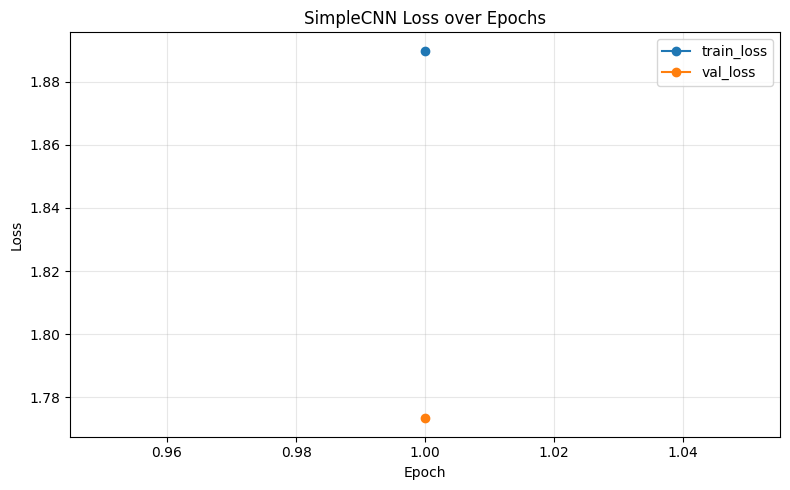

Saved figure to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\reports\figures\05_simple_cnn_loss_curve.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")

ax.set_title("SimpleCNN Loss over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

loss_fig_path = FIGURES_DIR / "05_simple_cnn_loss_curve.png"
fig.savefig(loss_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {loss_fig_path}")

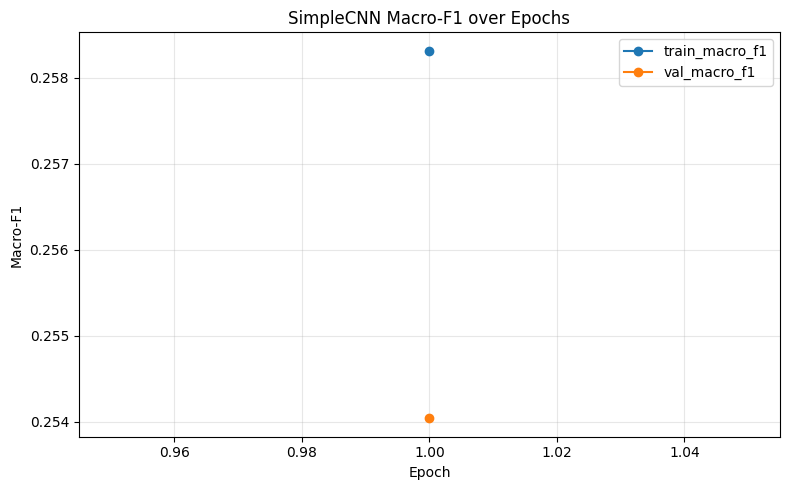

Saved figure to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\reports\figures\06_simple_cnn_macro_f1_curve.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="train_macro_f1")
ax.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val_macro_f1")

ax.set_title("SimpleCNN Macro-F1 over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro-F1")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

f1_fig_path = FIGURES_DIR / "06_simple_cnn_macro_f1_curve.png"
fig.savefig(f1_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {f1_fig_path}")

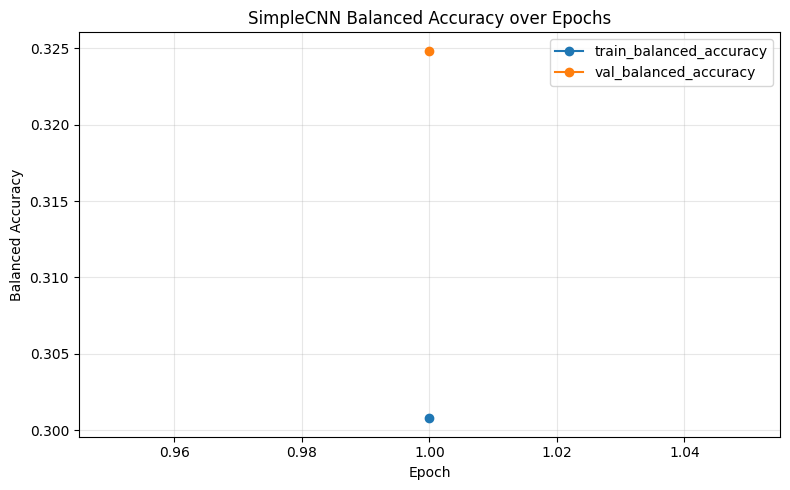

Saved figure to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\reports\figures\07_simple_cnn_balanced_accuracy_curve.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_df["epoch"],
    history_df["train_balanced_accuracy"],
    marker="o",
    label="train_balanced_accuracy",
)

ax.plot(
    history_df["epoch"],
    history_df["val_balanced_accuracy"],
    marker="o",
    label="val_balanced_accuracy",
)

ax.set_title("SimpleCNN Balanced Accuracy over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Balanced Accuracy")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

bal_acc_fig_path = FIGURES_DIR / "07_simple_cnn_balanced_accuracy_curve.png"
fig.savefig(bal_acc_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {bal_acc_fig_path}")

In [15]:
checkpoint = torch.load(best_model_path, map_location=device)

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

test_metrics, y_true, y_pred = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    return_predictions=True,
)

print("Best checkpoint epoch:", checkpoint["epoch"])
print("Validation macro-F1 at checkpoint:", checkpoint["val_macro_f1"])

print("\nTest metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

Best checkpoint epoch: 1
Validation macro-F1 at checkpoint: 0.2540424397360995

Test metrics:
accuracy: 0.3692
macro_f1: 0.3256
balanced_accuracy: 0.3906
loss: 1.7512


In [16]:
report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
)

print(report_text)

report_path = OUTPUTS_DIR / "simple_cnn_test_classification_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"Saved classification report to: {report_path}")

               precision    recall  f1-score   support

      ArtDeco       0.19      0.33      0.24         9
       Cubism       0.57      0.45      0.51        55
Impressionism       0.40      0.06      0.10        36
     Japonism       0.42      0.68      0.52        31
   Naturalism       0.32      0.18      0.23        33
       Rococo       0.35      0.50      0.41        18
      cartoon       0.21      0.64      0.31        11
        photo       0.30      0.29      0.29        21

     accuracy                           0.37       214
    macro avg       0.34      0.39      0.33       214
 weighted avg       0.40      0.37      0.35       214

Saved classification report to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\outputs\simple_cnn_test_classification_report.txt


,ArtDeco,Cubism,Impressionism,Japonism,Naturalism,Rococo,cartoon,photo
ArtDeco,3,2,0,2,0,0,0,2
Cubism,6,25,1,7,3,5,8,0
Impressionism,0,3,2,8,5,5,7,6
Japonism,0,4,0,21,2,0,3,1
Naturalism,5,4,1,8,6,1,4,4
Rococo,2,3,1,1,0,9,1,1
cartoon,0,2,0,0,1,1,7,0
photo,0,1,0,3,2,5,4,6


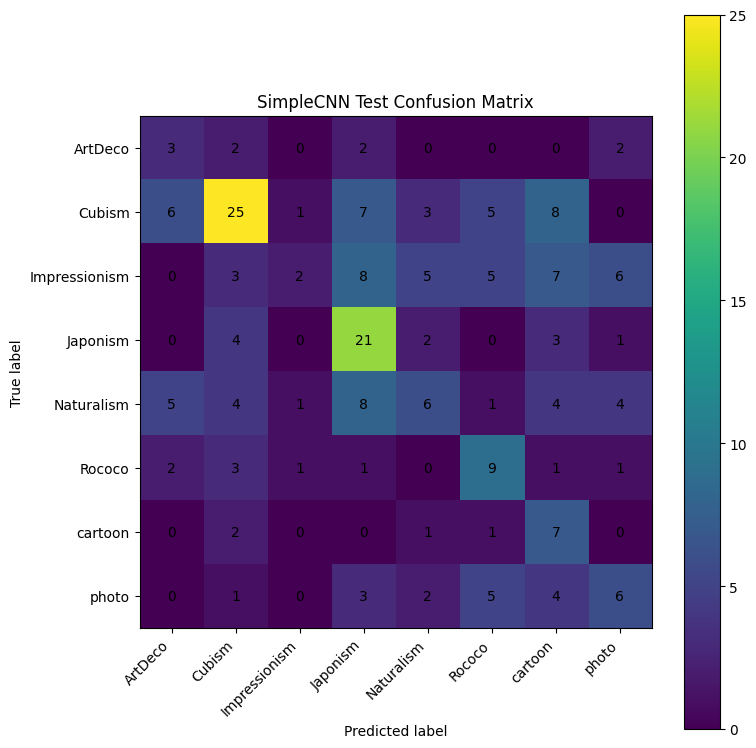

Saved confusion matrix CSV to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\outputs\simple_cnn_test_confusion_matrix.csv
Saved confusion matrix figure to: C:\Users\Anahi\OneDrive\Desktop\bostongene_project\Task_IML_2_data\image_classification_project\reports\figures\08_simple_cnn_test_confusion_matrix.png


In [17]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

cm_path = OUTPUTS_DIR / "simple_cnn_test_confusion_matrix.csv"
cm_df.to_csv(cm_path)

display(cm_df)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(cm)

ax.set_title("SimpleCNN Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()

cm_fig_path = FIGURES_DIR / "08_simple_cnn_test_confusion_matrix.png"
fig.savefig(cm_fig_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved confusion matrix CSV to: {cm_path}")
print(f"Saved confusion matrix figure to: {cm_fig_path}")